In [1]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision import models, transforms
from torchvision.datasets import ImageFolder

from torch.utils.data import (
    DataLoader,
    random_split,
    Subset,
    Dataset
)

from sklearn.metrics import accuracy_score

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [3]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

EUROSAT_PATH = "../dataset/EuroSAT"

dataset = ImageFolder(
    EUROSAT_PATH,
    transform=transform
)

In [4]:
train_size = int(0.8*len(dataset))
val_size = len(dataset)-train_size

random_train, random_val = random_split(

    dataset,

    [train_size,val_size],

    generator=torch.Generator().manual_seed(42)

)

In [5]:
indices = list(range(len(dataset)))

block_size = 500

blocks = [

    indices[i:i+block_size]

    for i in range(0,len(indices),block_size)

]

random.seed(42)

random.shuffle(blocks)

num_train_blocks = int(0.8*len(blocks))

train_blocks = blocks[:num_train_blocks]

val_blocks = blocks[num_train_blocks:]

train_indices = [

    idx

    for block in train_blocks

    for idx in block

]

val_indices = [

    idx

    for block in val_blocks

    for idx in block

]

spatial_train = Subset(dataset,train_indices)

spatial_val = Subset(dataset,val_indices)

In [6]:
random_loader = DataLoader(

    random_val,

    batch_size=32,

    shuffle=False

)

spatial_loader = DataLoader(

    spatial_val,

    batch_size=32,

    shuffle=False

)

In [7]:
model = models.resnet18(weights=None)

model.fc = nn.Linear(

    model.fc.in_features,

    10

)

model.load_state_dict(

    torch.load(

        "../models/resnet18_best.pth",

        map_location=device

    )

)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [8]:
def evaluate(model,loader):

    y_true=[]

    y_pred=[]

    with torch.no_grad():

        for images,labels in loader:

            images=images.to(device)

            outputs=model(images)

            _,pred=torch.max(outputs,1)

            y_true.extend(labels.numpy())

            y_pred.extend(pred.cpu().numpy())

    return accuracy_score(

        y_true,

        y_pred

    )

In [9]:
random_accuracy = evaluate(

    model,

    random_loader

)

spatial_accuracy = evaluate(

    model,

    spatial_loader

)

print("Random Split Accuracy :",random_accuracy)

print("Spatial Split Accuracy :",spatial_accuracy)

Random Split Accuracy : 0.8957407407407407
Spatial Split Accuracy : 0.894


In [10]:
comparison = pd.DataFrame({

    "Split Method":[

        "Random Split",

        "Spatial Block Split"

    ],

    "Accuracy (%)":[

        random_accuracy*100,

        spatial_accuracy*100

    ]

})

comparison

,Split Method,Accuracy (%)
0,Random Split,89.574074
1,Spatial Block Split,89.400000


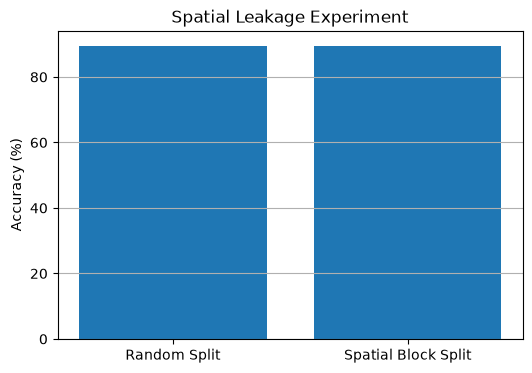

In [11]:
plt.figure(figsize=(6,4))

plt.bar(

    comparison["Split Method"],

    comparison["Accuracy (%)"]

)

plt.ylabel("Accuracy (%)")

plt.title("Spatial Leakage Experiment")

plt.grid(axis="y")

plt.show()

In [12]:
print("""

Interpretation

Random splitting generally produces higher validation accuracy because
images with similar visual characteristics may appear in both training
and validation sets.

Spatial block splitting evaluates the model on geographically separated
regions, making it a more realistic estimate of real-world performance.

""")



Interpretation

Random splitting generally produces higher validation accuracy because
images with similar visual characteristics may appear in both training
and validation sets.

Spatial block splitting evaluates the model on geographically separated
regions, making it a more realistic estimate of real-world performance.


